In [5]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# ===== 1. Generate Data =====
np.random.seed(42)
SAMPLES = 1000
x_values = np.random.uniform(0, 2 * np.pi, SAMPLES).astype(np.float32)
x_values = x_values / (2 * np.pi)
y_values = np.cos(x_values).astype(np.float32)
y_values += 0.1 * np.random.randn(SAMPLES).astype(np.float32)
indices = np.arange(SAMPLES)
np.random.shuffle(indices)
x_values = x_values[indices]
y_values = y_values[indices]
# Split: 60% train, 20% validation, 20% test
TRAIN = int(0.6 * SAMPLES)
VAL = int(0.8 * SAMPLES)
x_train, y_train = x_values[:TRAIN], y_values[:TRAIN]
x_val, y_val = x_values[TRAIN:VAL], y_values[TRAIN:VAL]
x_test, y_test = x_values[VAL:], y_values[VAL:]

In [6]:
# ===== 2. Build Model =====
model = keras.Sequential([
keras.layers.Dense(16, activation='relu', input_shape=(1,)),
keras.layers.Dense(16, activation='relu'),
keras.layers.Dense(1)
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(x_train, y_train,
epochs=500, batch_size=64,
validation_data=(x_val, y_val),
verbose=1)

Epoch 1/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0095 - mae: 0.0778 - val_loss: 0.0098 - val_mae: 0.0783
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0096 - mae: 0.0779 - val_loss: 0.0098 - val_mae: 0.0783
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0096 - mae: 0.0782 - val_loss: 0.0098 - val_mae: 0.0784
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0096 - mae: 0.0781 - val_loss: 0.0098 - val_mae: 0.0783
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0096 - mae: 0.0780 - val_loss: 0.0098 - val_mae: 0.0782
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0096 - mae: 0.0779 - val_loss: 0.0098 - val_mae: 0.0784
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0096 - mae: 0.0781 - val_loss: 0.0098 - val_mae: 0.0781
Epoch 8/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0097 - mae: 0.0785 - val_loss: 0.0098 - val_mae: 0.0785
Epoch 9/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss

In [8]:
# ===== 4. Evaluate =====
loss, mae = model.evaluate(x_test, y_test)
print(f"Test MAE: {mae:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0101 - mae: 0.0812 
Test MAE: 0.0812


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step  


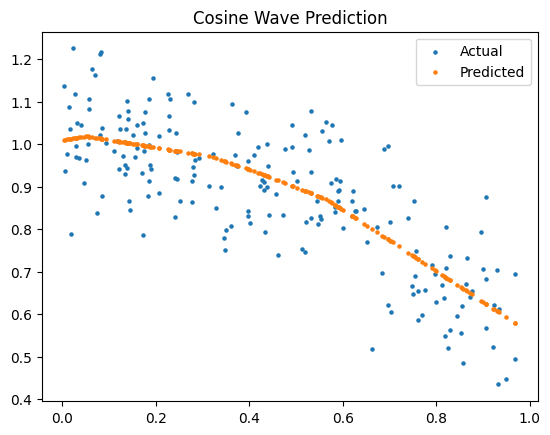

In [17]:
# Plot predictions vs actual
predictions = model.predict(x_test)
plt.scatter(x_test, y_test, label='Actual', s=5)
plt.scatter(x_test, predictions, label='Predicted', s=5)
plt.legend()
plt.title('Cosine Wave Prediction')
plt.show()

In [12]:
# ===== 5. Convert to TFLite =====
converter = tf.lite.TFLiteConverter.from_keras_model(model)
# Full integer quantization
converter.optimizations = [tf.lite.Optimize.DEFAULT]
def representative_dataset():
  for i in range(100):
    yield [np.array([[x_train[i]]], dtype=np.float32)]

converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
tflite_model = converter.convert()

# Save
with open('cosine_int8.tflite', 'wb') as f:
  f.write(tflite_model)
print(f"Model size: {len(tflite_model)} bytes")

Saved artifact at '/tmp/tmpm4jj8q89'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137123667828496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137123667832528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137123667830032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137123667834448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137123667836560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137123667833104: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model size: 3368 bytes


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Quantized MAE: 0.08093485
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


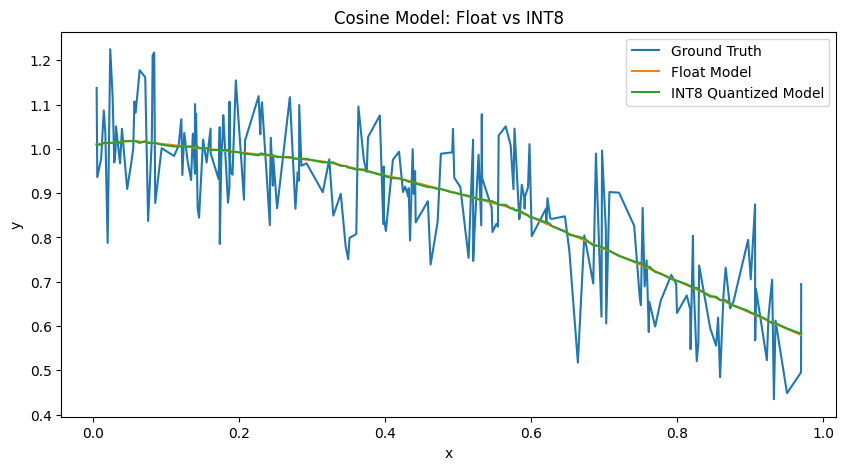

In [18]:
# ===== 6. Run Quantized TFLite Model =====
interpreter = tf.lite.Interpreter(model_path="cosine_int8.tflite")
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
input_scale, input_zero_point = input_details[0]['quantization']
output_scale, output_zero_point = output_details[0]['quantization']
int8_predictions = []
for x in x_test:
    x_input = np.array([[x]], dtype=np.float32)
    x_quantized = (x_input / input_scale + input_zero_point).astype(np.int8)
    interpreter.set_tensor(input_details[0]['index'], x_quantized)
    interpreter.invoke()
    output_quantized = interpreter.get_tensor(output_details[0]['index'])
    output = (output_quantized.astype(np.float32) - output_zero_point) * output_scale
    int8_predictions.append(output[0][0])
int8_predictions = np.array(int8_predictions)
quantized_mae = np.mean(np.abs(int8_predictions - y_test))
print("Quantized MAE:", quantized_mae)
float_predictions = model.predict(x_test).flatten()
sorted_indices = np.argsort(x_test)
plt.figure(figsize=(10, 5))
plt.plot(
    x_test[sorted_indices],
    y_test[sorted_indices],
    label='Ground Truth'
)
plt.plot(
    x_test[sorted_indices],
    float_predictions[sorted_indices],
    label='Float Model'
)
plt.plot(
    x_test[sorted_indices],
    int8_predictions[sorted_indices],
    label='INT8 Quantized Model'
)
plt.title('Cosine Model: Float vs INT8')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [19]:
# ===== 6. Convert to C Header =====
import binascii
hex_data = binascii.hexlify(tflite_model).decode('ascii')
c_array = ', '.join([
    '0x' + hex_data[i:i+2]
    for i in range(0, len(hex_data), 2)
])
header = f'''#ifndef COSINE_MODEL_H
#define COSINE_MODEL_H
#include <cstddef>
#include <cstdint>
alignas(8) const unsigned char g_model[] = {{
{c_array}
}};
const unsigned int g_model_len = {len(tflite_model)};
#endif // COSINE_MODEL_H
'''
with open('cosine_model.h', 'w') as f:
    f.write(header)
print("C header generated: cosine_model.h")

C header generated: cosine_model.h
